# 3. Evaluation

This notebook loads the saved model checkpoint, evaluates on the unseen test split, and generates the required metrics and visualizations.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

TEST_DIR = Path('../data/animals_dataset/test')
MODEL_PATH = Path('../models/best_model.pth')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


In [2]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

checkpoint = torch.load(MODEL_PATH, map_location=device)
class_names = checkpoint['class_names']

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f'Classes: {class_names}')
print(f'Test samples: {len(test_dataset)}')


Classes: ['cat', 'cow', 'deer', 'dog', 'lion']
Test samples: 82


In [ ]:
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_predictions.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

test_accuracy = accuracy_score(all_labels, all_predictions)
report_dict = classification_report(all_labels, all_predictions, target_names=class_names, output_dict=True)

print(f'Overall test accuracy: {test_accuracy * 100:.2f}%')
for class_name in class_names:
    m = report_dict[class_name]
    print(f"{class_name:<5} | Precision: {m['precision']:.4f} | Recall: {m['recall']:.4f} | F1: {m['f1-score']:.4f} | Support: {int(m['support'])}")
macro = report_dict['macro avg']
print(f"Macro averages | Precision: {macro['precision']:.4f} | Recall: {macro['recall']:.4f} | F1: {macro['f1-score']:.4f}")


In [4]:
report = classification_report(all_labels, all_predictions, target_names=class_names, digits=4)
report_path = RESULTS_DIR / 'classification_report.txt'

with report_path.open('w', encoding='utf-8') as file:
    file.write('ANIMAL CLASSIFICATION - TEST SET RESULTS\n')
    file.write('=' * 60 + '\n\n')
    file.write(f'Overall Test Accuracy: {test_accuracy * 100:.2f}%\n\n')
    file.write(report)

print(f'Classification report saved to {report_path}')


Classification report saved to ..\results\classification_report.txt


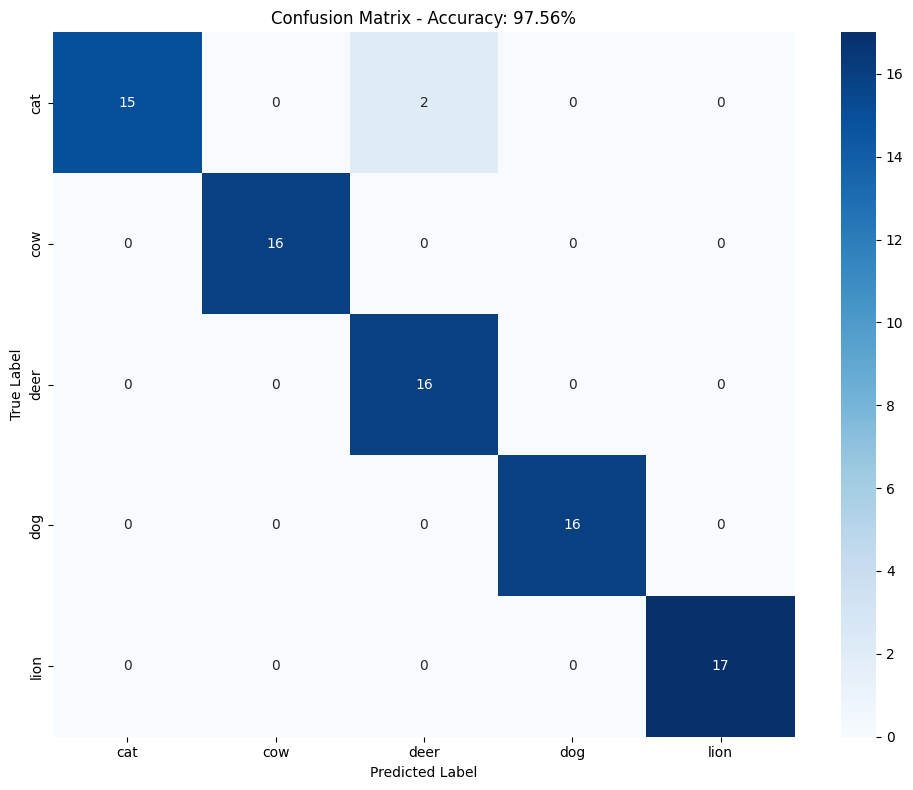

In [5]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix - Accuracy: {test_accuracy * 100:.2f}%')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


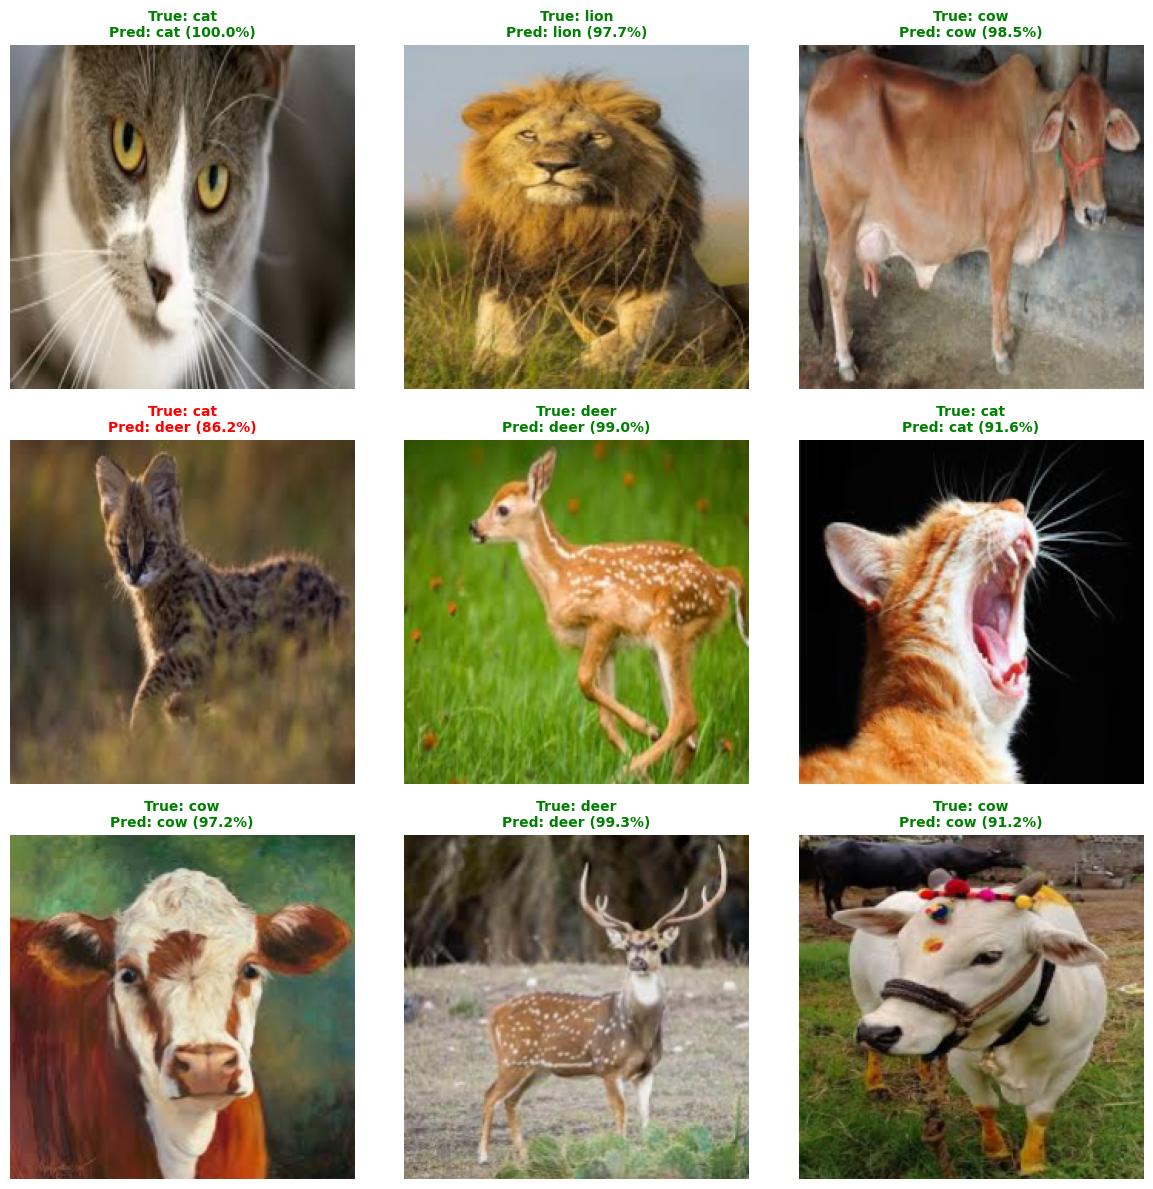

Evaluation complete.


In [6]:
indices = np.random.choice(len(test_dataset), size=min(9, len(test_dataset)), replace=False)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for plot_idx, sample_idx in enumerate(indices):
    img, true_label = test_dataset[sample_idx]
    display_img = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        probs = torch.softmax(output, dim=1)
        confidence, pred_label = torch.max(probs, dim=1)

    pred_label = pred_label.item()
    confidence = confidence.item()
    color = 'green' if pred_label == true_label else 'red'

    axes[plot_idx].imshow(display_img)
    axes[plot_idx].axis('off')
    axes[plot_idx].set_title(
        f'True: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence * 100:.1f}%)',
        color=color,
        fontsize=10,
        fontweight='bold',
    )

for remaining_ax in axes[len(indices):]:
    remaining_ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print('Evaluation complete.')
